# Introduction to Machine Learning in Python for HSS Research - Exercise 8

Welcome to the eight exercise! This exercise will work a bit differently than the ones before. It is designed to be an ongoing exercise (spanning 4 weeks) about training and evaluating different models for regression and classification:

- **Decision Trees**
- **Random Forests** / **Gradient Boosting**
- **Support Vector Machines** / **K-nearest Neighbors**
- **Neural Networks**

Please upload the finished notebook via ADAM, you can also see the submission deadline there. Use the name format **Ex08_IntroML_Firstname_Lastname.ipynb**.

***

### **This exercise must be passed in order to go on to the project and complete the exercise course!**

***

Before we can import the required packages, we must first make sure they are installed. Run the cell below to make sure:

In [1]:
!pip3 install pandas seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Now, we can import them:

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier

from sklearn.metrics import (
    confusion_matrix, 
    precision_score, 
    recall_score, 
    f1_score, 
    mean_squared_error, 
    r2_score
)

***

# Data Loading and Preparation

The code cells below load the respective datasets for regression and for classification tasks, define IVs and DPs, splits the datasets into train and test sets and creates a preprocessor.

This results in two train-test sets, one for each type of task:

- For **Regression**: X_train_reg, X_test_reg, y_train_reg, y_test_reg
- For **Classification**: X_train_class, X_test_class, y_train_class, y_test_class

**Make sure to use the correct train-test set for the correct task, or you will get errors / wrong results!**

## For Regression

We load the dataset for regression, print an overview, define the IVs (Independent Variables) and DP (Dependent Variable) and split the dataset into a train and test set:

In [3]:
# Load the ESS dataset
data_reg = pd.read_csv("ESS11_subset_regression.csv")

# Change 'urban', 'voted' and 'male' to categorical
data_reg['urban'] = data_reg['urban'].astype('category')
data_reg['voted'] = data_reg['voted'].astype('category')
data_reg['male'] = data_reg['male'].astype('category')

# Display a brief overview of the dataset
print("Dataset Overview:")
print(data_reg.info())

print("\nFirst few rows:")
print(data_reg.head())

# Define X (Independent Variables) and y (Dependent Variable)
X = data_reg.drop("trust", axis=1)
y = data_reg["trust"]

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y, test_size=0.3, random_state=42)

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   agea      1982 non-null   float64 
 1   eisced    1995 non-null   float64 
 2   hinctnta  1591 non-null   float64 
 3   hincfel   1982 non-null   float64 
 4   polintr   1997 non-null   float64 
 5   lrscale   1788 non-null   float64 
 6   psppsgva  1971 non-null   float64 
 7   cptppola  1983 non-null   float64 
 8   trust     2000 non-null   int64   
 9   urban     2000 non-null   category
 10  voted     2000 non-null   category
 11  male      2000 non-null   category
dtypes: category(3), float64(8), int64(1)
memory usage: 147.0 KB
None

First few rows:
   agea  eisced  hinctnta  hincfel  polintr  lrscale  psppsgva  cptppola  \
0  55.0     3.0       7.0      2.0      2.0      4.0       3.0       4.0   
1  77.0     1.0       2.0      2.0      4.0      NaN       NaN       1.0   


## For Classification

For classification tasks, we load the dataset for classification, print an overview, define the IVs (Independent Variables) and DP (Dependent Variable) and split the dataset into a train and test set:

In [4]:
# Load the ESS classification dataset
data_class = pd.read_csv("ESS11_subset_classification.csv")

# Change 'urban', 'voted', 'male' and 'high_trust' to categorical
data_class['urban'] = data_class['urban'].astype('category')
data_class['voted'] = data_class['voted'].astype('category')
data_class['male'] = data_class['male'].astype('category')
data_class['high_trust'] = data_class['high_trust'].astype('category')

# Display a brief overview of the dataset
print("Dataset Overview:")
print(data_class.info())

print("\nFirst few rows:")
print(data_class.head())

# Define X (Independent Variables) and y (Dependent Variable)
X = data_class.drop("high_trust", axis=1)
y = data_class["high_trust"]

# Split the data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y, test_size=0.3, random_state=42)

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   agea        1982 non-null   float64 
 1   eisced      1995 non-null   float64 
 2   hinctnta    1591 non-null   float64 
 3   hincfel     1982 non-null   float64 
 4   polintr     1997 non-null   float64 
 5   lrscale     1788 non-null   float64 
 6   psppsgva    1971 non-null   float64 
 7   cptppola    1983 non-null   float64 
 8   urban       2000 non-null   category
 9   voted       2000 non-null   category
 10  male        2000 non-null   category
 11  high_trust  2000 non-null   category
dtypes: category(4), float64(8)
memory usage: 133.4 KB
None

First few rows:
   agea  eisced  hinctnta  hincfel  polintr  lrscale  psppsgva  cptppola  \
0  55.0     3.0       7.0      2.0      2.0      4.0       3.0       4.0   
1  77.0     1.0       2.0      2.0      4.0      NaN      

## Create the Preprocessor

We define categorical and numerical features and create a preprocessor:

In [5]:
# Define categorical and numeric features
categorical_features = ['urban', 'voted', 'male']
numeric_features = ['agea', 'eisced', 'hinctnta', 'hincfel', 'polintr', 'lrscale', 'psppsgva', 'cptppola']

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Preprocessing for numerical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Combine preprocessors in a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Part 1: Decision Trees

## Regression

We build a pipeline for a **Decision Tree regression** and perform a grid search. **Note**: Executing this cell may take a couple of seconds due to the number of parameters and possible combinations! As you can see, we set ``random_state=42`` in the Decision Tree to keep the results repeatable, as Decision Trees introduce random elements and the results are **non-deterministic**.

In [6]:
# Create pipeline
pipe_DTR = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Define the parameter grid for Decision Tree regression
param_grid_DTR = {
    'regressor__criterion': ['absolute_error'],
    'regressor__splitter': ['best'],
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [2, 10],
    'regressor__min_samples_leaf': [1, 4],
    'regressor__max_features': ['sqrt', None],
    'regressor__max_leaf_nodes': [None, 20, 50]
}

# Perform grid search
grid_search_DTR = GridSearchCV(pipe_DTR, param_grid_DTR, cv=5,
                                scoring='neg_mean_squared_error',
                                verbose=1, n_jobs=-1, refit=False)

# Fit the grid search
grid_search_DTR.fit(X_train_reg, y_train_reg)

# Print the best parameters
print("Best Decision Tree Parameters:", grid_search_DTR.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Decision Tree Parameters: {'regressor__criterion': 'absolute_error', 'regressor__max_depth': 5, 'regressor__max_features': 'sqrt', 'regressor__max_leaf_nodes': 50, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 10, 'regressor__splitter': 'best'}


Take a look at ``param_grid_DTR`` and browse through the documentation for [Decision Tree Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html):
- what does ``max_depth`` mean?
- what does ``max_features`` mean?

In [7]:
# Write your answer here

# max_depth: maximum depth of the tree, basically how "big" the tree can get from top to bottom
# max_features: maximum number of features to consider when looking for the best split. Limiting features can speed up training and introduce randomness

As you can see, ``refit=`` has been set to ``False``, so we need to manually apply the best found parameters to the pipeline. For this, extract the ``.best_params_`` dictionary from the grid search and put them into the ``best_params`` variable. We will also create a fresh pipeline that should then use these best parameters. Remember to set ``random_state=42`` for the Decision Tree Regressor:

In [8]:
# Get best parameters
best_params = grid_search_DTR.best_params_

# Create a fresh pipeline for manual parameter application
best_pipe_DTR = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

You can use [``.set_params(**best_params)``](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.set_params) on this new pipeline to hand over all the best parameters. If you remember last time, we did this for every single parameter by itself. For a small amount of parameters, this is fine. But for a large number of them (as given here), this one line saves us lots of work:

In [9]:
# Set the best parameters for the pipeline
best_pipe_DTR.set_params(**best_params)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Now, fit this new best pipeline to the training data and make predictions based on the test data:

In [10]:
# Fit on the training data
best_pipe_DTR.fit(X_train_reg, y_train_reg)

# Predict on the test set
y_pred_reg = best_pipe_DTR.predict(X_test_reg)

Calculate the mean squared error and $R^2$ of the Decision Tree using the test data and the predictions of your model:

In [11]:
# Compute MSE and R2
mse_DTR = mean_squared_error(y_test_reg, y_pred_reg)
r2_DTR = r2_score(y_test_reg, y_pred_reg)

print("Test MSE Decision Tree:", mse_DTR)
print("Test R² Decision Tree:", r2_DTR)

Test MSE Decision Tree: 5.0075
Test R² Decision Tree: 0.2244046433324054


Compare these metrics to the ones from the Elastic Net regression. These were:
- MSE: 4.57
- $R^2$: 0.29

What do you notice? Is Decision Tree the better choice?

In [12]:
# Write your answers here

# MSE higher, R2 lower -> Performance slightly worse than Elastic Net, EN better choice

***

## Classification

Next, we will set up the pipeline with a **Decision Tree for classification**, define a parameter grid and perform a grid search in order to find out the best parameters. **Note**: This time, the automatic refit with the best parameters has **not** been turned off! So after the grid search, you can use the ``grid_search_DTC`` object for predictions.

In [13]:
# Create pipeline
pipe_DTC = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Define the parameter grid for Decision Tree classification
param_grid_DTC = {
    'classifier__criterion': ['gini'],
    'classifier__splitter': ['best'],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 10],
    'classifier__min_samples_leaf': [1, 4],
    'classifier__max_features': ['sqrt', None],
    'classifier__max_leaf_nodes': [None, 20, 50],
}

# Perform GridSearchCV with 5-fold cross-validation
grid_search_DTC = GridSearchCV(pipe_DTC, param_grid_DTC, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_DTC.fit(X_train_class, y_train_class)

# Print the best parameters
print("Best Decision Tree Parameters:", grid_search_DTC.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Decision Tree Parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__max_leaf_nodes': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__splitter': 'best'}


Use the (automatically) fitted grid search to predict y based on the test data:

In [14]:
# Predict y based on test data
y_pred_class = grid_search_DTC.predict(X_test_class)

Compute the confusion matrix for your Decision Tree:

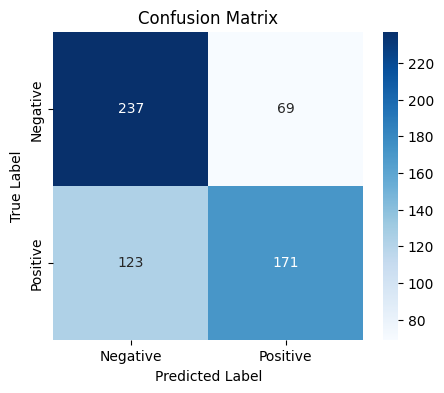

In [15]:
# Compute the confusion matrix
cm = confusion_matrix(y_test_class, y_pred_class)

# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

What's your interpretation of the matrix? How does it compare to the one from the Logistic Regression? For reference, it looked like this:

$$
\begin{bmatrix}
239 & 67 \\
123 & 171
\end{bmatrix}
$$

In [16]:
# Write your answer here

# Very close results, bottom tiles identical, top tiles slightly different

Compute the precision, recall and F1-score for the Decision Tree:

In [17]:
# Compute precision, recall, and F1-score
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)

print(f"Tree Precision: {precision:.4f}")
print(f"Tree Recall: {recall:.4f}")
print(f"Tree F1-score: {f1:.4f}")

Tree Precision: 0.7125
Tree Recall: 0.5816
Tree F1-score: 0.6404


What's your interpretation of these results and how do they compare to a Logistic Regression? Is Decision Tree the better choice? For reference, the results of the logistic regression model were:
- Precision: 0.72
- Recall: 0.58
- F1-score: 0.64

In [18]:
# Write your answer here

# Precision: slightly worse than logistic
# Recall: identical with logistic
# F1-score: identical with logistic
# Given these metrics, logistic seems slightly better

***

# Part 2: Random Forests / Gradient Boosting

## Regression

We build a pipeline for a **Random Forest regression** and perform a grid search. **Note**: Executing the below cell may take **around two minutes or more** due to the number of parameters, possible combinations and the complexity of a Random Forest! The duration is heavily dependant on your computer. As you can see, we set ``random_state=42`` in the Random Forest to keep the results repeatable. As the name implies, Random Forests introduce random elements and the results are therefore **non-deterministic** if you leave ``random_state`` blank.

In [19]:
# Create pipeline
pipe_RFR = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Define parameter grid for Random Forest regression
param_grid_RFR = {
    'regressor__criterion': ['absolute_error'],
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [10, 20, 30],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [2, 4, 8],
    'regressor__max_features': ['sqrt', 'log2'],
    'regressor__bootstrap': [True]
}

# Perform grid search
grid_search_RFR = GridSearchCV(pipe_RFR, param_grid_RFR, cv=5,
                                scoring='neg_mean_squared_error',
                                verbose=1, n_jobs=-1, refit=False)

# Fit the grid search
grid_search_RFR.fit(X_train_reg, y_train_reg)

# Print the best parameters
print("Best Random Forest Parameters:", grid_search_RFR.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest Parameters: {'regressor__bootstrap': True, 'regressor__criterion': 'absolute_error', 'regressor__max_depth': 10, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}


Take a look at ``param_grid_RFR`` and browse through the documentation for [Random Forest Regressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html):
- what does ``n_estimators`` mean?
- what does ``min_samples_leaf`` mean?

In [20]:
# Write your answer here

# n_estimators: the number of trees in the forest, size of the forest
# min_samples_leaf: minimum number of samples required to be at a leaf node

Again, ``refit=`` has been set to ``False``, so we need to manually apply the best found parameters to the pipeline. For this, extract the ``.best_params_`` dictionary from the grid search and put them into the ``best_params`` variable. We will also create a fresh pipeline that should then use these best parameters. Remember to set ``random_state=42`` for the Random Forest Regressor:

In [21]:
# Get best parameters
best_params = grid_search_RFR.best_params_

# Create a fresh pipeline for manual parameter application
best_pipe_RFR = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

Plug the best parameters into the pipeline. You can use [``.set_params(**best_params)``](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline.set_params) on this new pipeline for this. **Note**: The two stars (**) mean that you are unpacking a dictionary into keyword arguments. It's a way to pass parameters stored in a dictionary to a function.

In [22]:
# Set the best parameters for the pipeline
best_pipe_RFR.set_params(**best_params)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Fit this new best pipeline to the training data and make predictions based on the test data:

In [23]:
# Fit on the training data
best_pipe_RFR.fit(X_train_reg, y_train_reg)

# Predict on the test set
y_pred_reg = best_pipe_RFR.predict(X_test_reg)

Calculate the mean squared error and $R^2$ of the Random Forest using the test data and the predictions of your model:

In [24]:
# Compute MSE and R2
mse_RFR = mean_squared_error(y_test_reg, y_pred_reg)
r2_RFR = r2_score(y_test_reg, y_pred_reg)

print("Random Forest MSE:", mse_RFR)
print("Random Forest R²:", r2_RFR)

Random Forest MSE: 4.591802611111111
Random Forest R²: 0.28879065723176944


Compare these metrics to the ones from Elastic Net and Decision Tree.

What do you notice? How does the Random Forest compare?

In [25]:
# Write your answers here

# Better metrics than Decision Tree, but still very slightly worse than Elastic Net

***

## Classification

Next, we will set up the pipeline with a **Random Forest for classification**, define a parameter grid and perform a grid search in order to find out the best parameters. **Note**: This time, the automatic refit with the best parameters has **not** been turned off! So after the grid search, you can use the ``grid_search_RFC`` object for predictions.

In [26]:
# Create pipeline
pipe_RFC = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define the parameter grid for Random Forest classification
param_grid_RFC = {
    'classifier__criterion': ['gini'],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [2, 4, 8],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__bootstrap': [True]
}

# Perform GridSearchCV with 5-fold cross-validation
grid_search_RFC = GridSearchCV(pipe_RFC, param_grid_RFC, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_RFC.fit(X_train_class, y_train_class)

# Print the best parameters
print("Best Random Forest Parameters:", grid_search_RFC.best_params_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Random Forest Parameters: {'classifier__bootstrap': True, 'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}


Use the (automatically) fitted grid search to predict y based on the test data:

In [27]:
# Predict y based on test data
y_pred_class = grid_search_RFC.predict(X_test_class)

Compute the confusion matrix for your Random Forest:

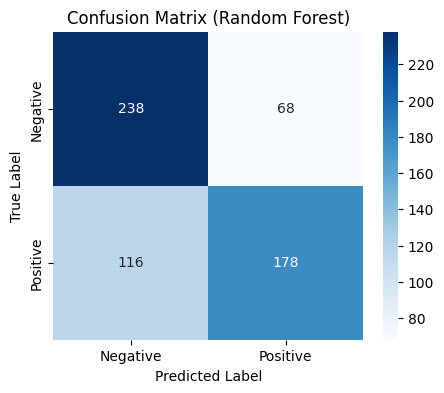

In [28]:
# Compute the confusion matrix
cm = confusion_matrix(y_test_class, y_pred_class)

# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

What's your interpretation of the matrix? How does it compare to the previous ones?

In [29]:
# Write your answer here

# More TNs than DT but less than LR, bottom tiles show more true positives than both. Overall very close performance

Compute the precision, recall and F1-score for the Random Forest:

In [30]:
# Compute precision, recall, and F1-score
precision = precision_score(y_test_class, y_pred_class)
recall = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)

print(f"Random Forest Precision: {precision:.4f}")
print(f"Random Forest Recall: {recall:.4f}")
print(f"Random Forest F1-score: {f1:.4f}")

Random Forest Precision: 0.7236
Random Forest Recall: 0.6054
Random Forest F1-score: 0.6593


What's your interpretation of these results and how do they compare to the ones from Logistic Regression and Decision Tree?

In [31]:
# Write your answer here

# Precision: identical to logistic
# Recall: slightly higher than logistic and dt
# F1-score: slightly higher than logistic and dt
# Given these metrics, random forest seems like the best model so far for classification

***

## Classification using Gradient Boosting

For this next part, try to implement **Gradient Boosting for classification** via sklearn yourself. What you need to do:

- Define a new pipeline for Gradient Boosting with ``GradientBoostingClassifier``. You can reuse the preprocessor from before. For Gradient Boosting, use a ``random_state`` of 42.
- Come up with a parameter grid. Try to find a balance between a variety of values and performance.
- Perform a grid search with 5-fold cross-validation and ``"accuracy"`` for ``scoring``.
- Predict y values using the test data.

Try to look at the official [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) for further information and hints.

In [32]:
# Define sklearn Gradient Boosting pipeline
pipe_GBC = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Define parameter grid
param_grid_GBC = {
    'classifier__n_estimators': [300, 400, 500],
    'classifier__learning_rate': [0.005, 0.01, 0.02],
    'classifier__max_depth': [2, 3, 4],
    'classifier__subsample': [0.9, 1.0],
    'classifier__min_samples_split': [2, 4],
    'classifier__min_samples_leaf': [2, 3, 4]
}

# Perform grid search
grid_search_GBC = GridSearchCV(pipe_GBC, param_grid_GBC, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit grid search
grid_search_GBC.fit(X_train_class, y_train_class)

# Print the best found parameters
print("Best GradientBoostingClassifier Parameters:", grid_search_GBC.best_params_)

# Predict
y_pred_gbc = grid_search_GBC.predict(X_test_class)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best GradientBoostingClassifier Parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}


Compute the confusion matrix for this model:

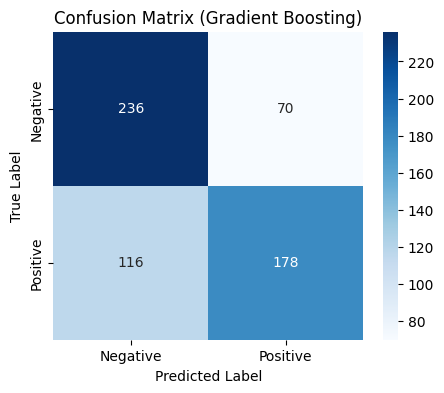

In [33]:
# Compute the confusion matrix
cm = confusion_matrix(y_test_class, y_pred_gbc)

# Plot the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Gradient Boosting)")
plt.show()

Compare this confusion matrix with the ones from before. What do you notice?

In [34]:
# Write your answer here

# TPs same as Random Forest, lowest amount of TNs so far -> Performance comparable, but not clearly better than any alternative

Compute Precision, Recall and the F1-score for this model:

In [35]:
# Compute precision, recall, and F1-score
precision = precision_score(y_test_class, y_pred_gbc)
recall = recall_score(y_test_class, y_pred_gbc)
f1 = f1_score(y_test_class, y_pred_gbc)

print(f"XGB Precision: {precision:.4f}")
print(f"XGB Recall: {recall:.4f}")
print(f"XGB F1-score: {f1:.4f}")

XGB Precision: 0.7177
XGB Recall: 0.6054
XGB F1-score: 0.6568


Compare these results with the ones from before. How does Gradient Boosting perform in this case?

In [36]:
# Write your answer here

# Performance very close to Random Forest, not a clear winner

***

# Part 3: Support Vector Machines / K-nearest Neighbors

**Note: This exercise will work slightly differently from before: your task is to *either* implement a Support Vector Machine for regression *or* K-nearest neighbors for classification using the same dataset and research questions as for the last couple of exercises. Loading the data etc. will be provided, but you will have to set up the entire preprocessor, pipeline etc. by yourself. You are allowed to use material from previous exercises for this, but for the best learning effect, try coding everything from scratch.**

## Option 1: Support Vector Machine (Regression)

Create a pipeline with a [Support Vector Machine for regression](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) and an appropriate parameter grid:

In [37]:
# Pipeline for Support Vector Regression
pipe_SVR = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', SVR())
])

# Parameter grid for Support Vector Regression
param_grid_SVR = {
    'regressor__kernel': ['rbf', 'linear'],
    'regressor__C': [0.1, 1, 10],
    'regressor__epsilon': [0.1, 0.2, 0.5],
    'regressor__gamma': ['scale', 'auto']
}

Perform a grid search with a ``cv`` of ``5`` and ``"neg_mean_squared_error"`` for ``scoring`` to find the best parameters:

In [38]:
# Perform grid search
grid_search_SVR = GridSearchCV(pipe_SVR, param_grid_SVR, cv=5,
                               scoring='neg_mean_squared_error',
                               verbose=1, n_jobs=-1)

grid_search_SVR.fit(X_train_reg, y_train_reg)

print("Best SVR Parameters:", grid_search_SVR.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best SVR Parameters: {'regressor__C': 0.1, 'regressor__epsilon': 0.5, 'regressor__gamma': 'scale', 'regressor__kernel': 'linear'}


Predict values using the test set and compute MSE as well as $R^2$:

In [39]:
# Predict on the test set
y_pred_SVR = grid_search_SVR.predict(X_test_reg)

# Compute MSE and R2
mse_SVR = mean_squared_error(y_test_reg, y_pred_SVR)
r2_SVR = r2_score(y_test_reg, y_pred_SVR)

print("SVR MSE:", mse_SVR)
print("SVR R²:", r2_SVR)

SVR MSE: 4.571692380587298
SVR R²: 0.2919054653028198


Compare these metrics to the ones from Elastic Net, Decision Tree and Random Forest.

What do you notice? How does your Support Vector Machine compare?

In [40]:
# Write your answers here

# Identical with Elastic Net, better than DT and RF

***

## Option 2: K-nearest Neighbors (Classification)

Create a pipeline with [K-nearest Neighbor for classification](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) and an appropriate parameter grid. In this grid, make sure to use ``'euclidean'`` as ``'metric'``. For simplicity, focus on ``'n_neighbors'`` and ``'weights'`` as parameters:

In [41]:
# Create the pipeline with KNN
pipe_KNN = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# Define the parameter grid for KNN
param_grid_KNN = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean']
}

Perform a grid search with a ``cv`` of ``5`` and ``"accuracy"`` for ``scoring`` to find the best parameters:

In [42]:
# GridSearchCV setup
grid_search_KNN = GridSearchCV(pipe_KNN, param_grid_KNN, cv=5,
                               scoring='accuracy', verbose=1, n_jobs=-1)

# Fit to training data
grid_search_KNN.fit(X_train_class, y_train_class)

print("Best SVR Parameters:", grid_search_KNN.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVR Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 15, 'classifier__weights': 'uniform'}


Predict values using the test set and compute the confusion matrix as well as precision, recall and F1-score:

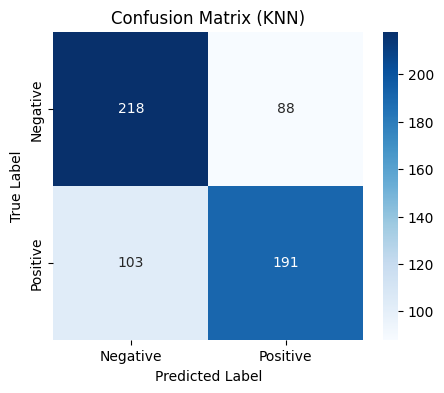

KNN Precision: 0.6846
KNN Recall: 0.6497
KNN F1-score: 0.6667


In [43]:
# Predict on test set
y_pred_class_KNN = grid_search_KNN.predict(X_test_class)

# Confusion Matrix
cm_KNN = confusion_matrix(y_test_class, y_pred_class_KNN)

plt.figure(figsize=(5,4))
sns.heatmap(cm_KNN, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (KNN)")
plt.show()

# Classification metrics
precision_KNN = precision_score(y_test_class, y_pred_class_KNN)
recall_KNN = recall_score(y_test_class, y_pred_class_KNN)
f1_KNN = f1_score(y_test_class, y_pred_class_KNN)

print(f"KNN Precision: {precision_KNN:.4f}")
print(f"KNN Recall: {recall_KNN:.4f}")
print(f"KNN F1-score: {f1_KNN:.4f}")

Compare these metrics to the ones from Logistic Regression, Decision Tree and Random Forest. How does KNN compare?

In [44]:
# Write your answer here

# Highest number of TPs so far, but also highest amount of FPs
# Lowest Precision out of all models but highest recall, F1 highest out of all when rounded

***

# Part 4: Neural Networks

**Note: This part of the exercise works just like the last one: Your task is to *either* implement a Neural Network for regression *or* for classification. As last time, loading the data etc. will be provided, but you will have to set up the entire preprocessor, pipeline etc. by yourself.**

## Option 1: Neural Network for Regression

Create a pipeline with a [Multi-layer Perceptron for Regression](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html) and an appropriate parameter grid. For the MLPRegressor, set ``max_iter`` to 1000, ``random_state`` to 42 and ``early_stopping`` to True. For the parameter grid, use two configurations of hidden layers:

- One with two layers of sizes 100 and 50
- Another with a single layer of 100 neurons

The sizes of the hidden layers are given as tuples, so (1, 2) would be two hidden layers with 1 and 2 neurons respectively. Make sure to include both ``'relu'`` and ``'tanh'`` for ``'activation'``, as well as different values for ``alpha`` and ``learning_rate``.

In [45]:
# Pipeline for Neural Network Regression
pipe_NNR = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', MLPRegressor(max_iter=1000, random_state=42, early_stopping=True))
])

# Parameter grid for Neural Network
param_grid_NNR = {
    'regressor__hidden_layer_sizes': [(100, 50), (100,)],
    'regressor__activation': ['relu', 'tanh'],
    'regressor__alpha': [0.0001, 0.001, 0.01, 0.1],
    'regressor__learning_rate': ['constant', 'adaptive']
}

Perform a grid search with a ``cv`` of ``5`` and ``"neg_mean_squared_error"`` for ``scoring`` to find the best parameters.  **Note**: Depending on parameters, grid search for Neural Networks can take a long time.

In [46]:
# Perform grid search
grid_search_NNR = GridSearchCV(pipe_NNR, param_grid_NNR, cv=5,
                              scoring='neg_mean_squared_error',
                              verbose=1, n_jobs=-1)

grid_search_NNR.fit(X_train_reg, y_train_reg)

print("Best Neural Network Parameters:", grid_search_NNR.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Neural Network Parameters: {'regressor__activation': 'tanh', 'regressor__alpha': 0.1, 'regressor__hidden_layer_sizes': (100, 50), 'regressor__learning_rate': 'constant'}


Predict values using the test set and compute MSE as well as $R^2$:

In [47]:
# Predict on the test set
y_pred_NN = grid_search_NNR.predict(X_test_reg)

# Compute MSE and R2
mse_NN = mean_squared_error(y_test_reg, y_pred_NN)
r2_NN = r2_score(y_test_reg, y_pred_NN)

print("Neural Network MSE:", mse_NN)
print("Neural Network R²:", r2_NN)

Neural Network MSE: 4.545410391018119
Neural Network R²: 0.2959761970200123


Compare these metrics to the ones from Elastic Net, Decision Tree, Random Forest and Support Vector Machine.

What do you notice? How does your Neural Network compare?

In [48]:
# Write your answers here

# Lowest MSE so far with high R2, seems to be the best model

***

## Option 2: Neural Network for Classification

Create a pipeline with a [Multi-layer Perceptron for Classification](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html) and an appropriate parameter grid. For the MLPClassifier, set ``max_iter`` to 1000, ``random_state`` to 42 and ``early_stopping`` to True. For the parameter grid, use two configurations of hidden layers:

- One with two layers of sizes 100 and 50
- Another with a single layer of 100 neurons

The sizes of the hidden layers are given as tuples, so (1, 2) would be two hidden layers with 1 and 2 neurons respectively. Make sure to include both ``'relu'`` and ``'tanh'`` for ``'activation'``, as well as different values for ``alpha`` and ``learning_rate``.

In [49]:
# Create the pipeline with Neural Network Classifier
pipe_NNC = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(max_iter=1000, random_state=42, early_stopping=True))
])

# Define the parameter grid for MLPClassifier
param_grid_NNC = {
    'classifier__hidden_layer_sizes': [(100, 50), (100,)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate': ['constant', 'adaptive']
}

Perform a grid search with a ``cv`` of ``5`` and ``"accuracy"`` for ``scoring`` to find the best parameters.  **Note**: Depending on parameters, grid search for Neural Networks can take a long time. For the sake of this exercise, try to target a time of ~ 2 minutes.

In [50]:
# GridSearchCV setup
grid_search_NNC = GridSearchCV(pipe_NNC, param_grid_NNC, cv=5,
                              scoring='accuracy', verbose=1, n_jobs=-1)

# Fit to training data
grid_search_NNC.fit(X_train_class, y_train_class)

print("Best Neural Network Parameters:", grid_search_NNC.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Neural Network Parameters: {'classifier__activation': 'relu', 'classifier__alpha': 0.001, 'classifier__hidden_layer_sizes': (100, 50), 'classifier__learning_rate': 'constant'}


Predict values using the test set and compute the confusion matrix as well as precision, recall and F1-score:

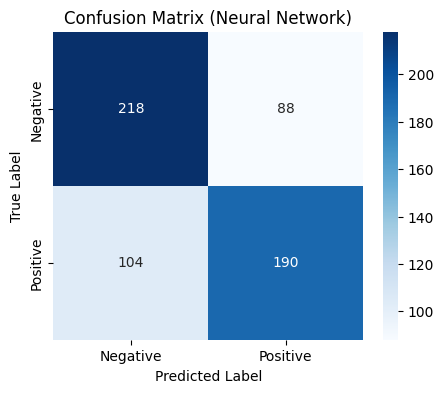

Neural Network Precision: 0.6835
Neural Network Recall: 0.6463
Neural Network F1-score: 0.6643


In [51]:
# Predict on test set
y_pred_class_NN = grid_search_NNC.predict(X_test_class)

# Confusion Matrix
cm_NN = confusion_matrix(y_test_class, y_pred_class_NN)

plt.figure(figsize=(5,4))
sns.heatmap(cm_NN, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Neural Network)")
plt.show()

# Classification metrics
precision_NN = precision_score(y_test_class, y_pred_class_NN)
recall_NN = recall_score(y_test_class, y_pred_class_NN)
f1_NN = f1_score(y_test_class, y_pred_class_NN)

print(f"Neural Network Precision: {precision_NN:.4f}")
print(f"Neural Network Recall: {recall_NN:.4f}")
print(f"Neural Network F1-score: {f1_NN:.4f}")

Compare these metrics to the ones from Logistic Regression, Decision Tree, Random Forest and KNN. How does the Neural Network compare?

In [52]:
# Write your answer here

# TPs worse than KNN, TNs identical with KNN
# Precision slightly better than KNN, Recall identical, F1 identical to RF